# CIFAR-10 Classification with CNNs

This notebook implements and compares three different CNN architectures for multi-class image classification using the CIFAR-10 dataset in PyTorch. The goal is is to understand how changes in the network design impact performance on 32x32 color images across 10 classes.

In [1]:
import random

import torch.nn as nn
import torch
from torch.optim import Adam
from torch.utils.data import Dataset, DataLoader
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
from tqdm import tqdm

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.cuda.is_available()

True

### Load data

CIFAR-10 is a dataset of 60,000 color images (32x32 pixels with 3 channels), divided into 50,000 training images and 10,000 test images. It includes 10 classes: airplane, automobile, bird, cat, deer, dog, frog, horse, ship, and truck.

When loading the dataset,images are returned as PIL images by default. To work with them in PyTorch, they are converted into tensors using transforms.ToTensor(), which also scales pixel values from [0, 255] to [0, 1]. After that, normalization is applied using the standard mean and standard deviation values for each channel in CIFAR-10

In [3]:
cifar_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465),
                         (0.2470, 0.2435, 0.2616))
])

raw_train = torchvision.datasets.CIFAR10(root="../data/cifar10_data", train=True,
                                          download=True, transform=cifar_transform)
raw_test  = torchvision.datasets.CIFAR10(root="../data/cifar10_data", train=False,
                                          download=True, transform=cifar_transform)

class_names = raw_train.classes
print("CIFAR-10 root: ../data/cifar10_data")
print(f"Training samples:{len(raw_train)}")
print(f"Test samples:{len(raw_test)}")
print(f"Classes:{class_names}")

Files already downloaded and verified
Files already downloaded and verified
CIFAR-10 root: ../data/cifar10_data
Training samples:50000
Test samples:10000
Classes:['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


In [4]:
def show(img, lbl):
    mean = torch.tensor([0.4914, 0.4822, 0.4465])
    std  = torch.tensor([0.2470, 0.2435, 0.2616])
    img_show = img.clone()
    for c in range(3):
        img_show[c] = img_show[c] * std[c] + mean[c]
    plt.figure(figsize=(3, 3))
    plt.title(class_names[lbl], fontdict={'fontsize': 16})
    plt.axis('off')
    plt.imshow(img_show.clamp(0, 1).permute(1, 2, 0))

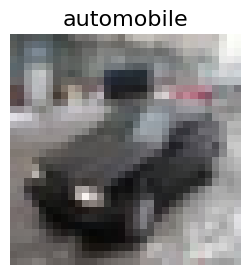

In [5]:
rnd_idx = random.randint(0, len(raw_train) - 1)
image, label = raw_train[rnd_idx]
show(image, label)

## Preparing dataset

The CIFAR-10 dataset provides images and labels for training. Images are converted to tensors and scaled to [0,1]. since they are 32x32 rgb images, they are handled as color images.

In [6]:
IMG_HEIGHT = 32
IMG_WIDTH = 32
IMG_CHANNELS = 3
NUM_CLASSES = 10

class CifarDataset(Dataset):
    def __init__(self, base_dataset):
        imgs = []
        lbls = []
        for img, lbl in base_dataset:
            imgs.append(img)
            lbls.append(lbl)
        self.xs = torch.stack(imgs).float().to(device)
        self.ys = torch.tensor(lbls).long().to(device)

    def __getitem__(self, idx):
        x = self.xs[idx]
        y = self.ys[idx]
        return x, y

    def __len__(self):
        return len(self.xs)

In [7]:
train_data = CifarDataset(raw_train)
test_data  = CifarDataset(raw_test)

In [8]:
batch_size = 128

train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True)
test_loader  = DataLoader(test_data,  batch_size=batch_size, shuffle=False)

## Training functions

Now the training functions can be defined. An additional function to calculate accuracy is also included to evaluate the model.

In [9]:
def get_batch_accuracy(output, y, N):
    pred = output.argmax(dim=1, keepdim=True)
    correct = pred.eq(y.view_as(pred)).sum().item()
    return correct / N

The training function runs the complete training loop. Foreach epoch,it tracks the training loss and accuracy, and then evaluates the model on the test set. it returns the loss and accuracy values for both training and testing so they can be plotted later.Since validation is not required, the test set is used directly to monitor performance over time.


In [10]:
def train(_model, _train_loader, _test_loader, _criterion, _optimizer, _num_epochs):
    res = {
        'train_loss': [],
        'train_acc': [],
        'test_loss': [],
        'test_acc': [],
    }
    iterator = tqdm(range(_num_epochs), desc="Training", unit="epoch")

    for _ in iterator:
        _model.train()
        train_loss = 0.0
        train_acc = 0.0
        for X_batch, y_batch in _train_loader:
            _optimizer.zero_grad()
            outputs = _model(X_batch)
            loss = _criterion(outputs, y_batch)
            loss.backward()
            _optimizer.step()
            train_loss += loss.item() * X_batch.size(0)
            train_acc += get_batch_accuracy(outputs, y_batch, len(_train_loader.dataset))

        epoch_train_loss = train_loss / len(_train_loader.dataset)

        _model.eval()
        test_loss = 0.0
        test_acc = 0.0
        with torch.no_grad():
            for X_test, y_test in _test_loader:
                test_outputs = _model(X_test)
                test_loss += _criterion(test_outputs, y_test).item() * X_test.size(0)
                test_acc += get_batch_accuracy(test_outputs, y_test, len(_test_loader.dataset))

        epoch_test_loss = test_loss / len(_test_loader.dataset)

        iterator.set_postfix(
            train_loss=f"{epoch_train_loss:.4f}",
            train_acc=f"{train_acc:.4f}",
            test_loss=f"{epoch_test_loss:.4f}",
            test_acc=f"{test_acc:.4f}",
        )

        res['train_loss'].append(epoch_train_loss)
        res['train_acc'].append(train_acc)
        res['test_loss'].append(epoch_test_loss)
        res['test_acc'].append(test_acc)

    return res

This function evaluates the model on the test set once training is finished, computing the average loss and accuracy across all samples

In [11]:
def test(_model, _test_loader, _loss_function):
    _model.eval()
    test_loss = 0.0
    test_acc = 0.0
    with torch.no_grad():
        for x, y in _test_loader:
            output = _model(x)
            test_loss += _loss_function(output, y).item() * x.size(0)
            test_acc += get_batch_accuracy(output, y, len(_test_loader.dataset))

    return (test_loss / len(_test_loader.dataset)), test_acc

## Training the models

All three models are trained with the same hyperparameters. The only thing that changes between them is the architecture of the network.

### Model 1

A simple two-layer CNN without any regularization. It uses two convolutional layers with max pooling, thena a fully connected layer. This model is used as a baseline to compare with the other architectures.

In [12]:
model_a = nn.Sequential(
    nn.Conv2d(IMG_CHANNELS, 32, 3, stride=1, padding=1), 
    nn.ReLU(),
    nn.MaxPool2d(2, stride=2),                             # 32 x 16 x 16

    nn.Conv2d(32, 64, 3, stride=1, padding=1),             # 64 x 16 x 16
    nn.ReLU(),
    nn.MaxPool2d(2, stride=2),                             # 64 x 8 x 8

    nn.Flatten(),
    nn.Linear(64 * 8 * 8, 256),
    nn.ReLU(),
    nn.Linear(256, NUM_CLASSES)
)

model_a = model_a.to(device)

In [13]:
epochs = 30
loss_function = nn.CrossEntropyLoss()
optimizer = Adam(model_a.parameters())

res_a = train(model_a, train_loader, test_loader, loss_function, optimizer, epochs)

Training: 100%|██████████| 30/30 [01:53<00:00,  3.79s/epoch, test_acc=0.7052, test_loss=2.5006, train_acc=0.9921, train_loss=0.0247]


In [14]:
a_test_loss, a_test_acc = test(model_a, test_loader, loss_function)

### Model 2

This model adds a third convolutional layer, batch normalization after each conv and dropout before the fully connected layers. This structure helps capture more complex patterns,while batch normalization and dropout help reduce overfitting

In [15]:
model_b = nn.Sequential(
    nn.Conv2d(IMG_CHANNELS, 32, 3, stride=1, padding=1),   # 32 x 32 x 32
    nn.BatchNorm2d(32),
    nn.ReLU(),
    nn.MaxPool2d(2, stride=2),                              # 32 x 16 x 16

    nn.Conv2d(32, 64, 3, stride=1, padding=1),              # 64 x 16 x 16
    nn.BatchNorm2d(64),
    nn.ReLU(),
    nn.MaxPool2d(2, stride=2),                              # 64 x 8 x 8

    nn.Conv2d(64, 128, 3, stride=1, padding=1),             # 128 x 8 x 8
    nn.BatchNorm2d(128),
    nn.ReLU(),
    nn.MaxPool2d(2, stride=2),                              # 128 x 4 x 4

    nn.Flatten(),
    nn.Dropout(0.3),
    nn.Linear(128 * 4 * 4, 256),
    nn.ReLU(),
    nn.Dropout(0.3),
    nn.Linear(256, NUM_CLASSES)
)

model_b = model_b.to(device)

In [16]:
epochs = 30
loss_function = nn.CrossEntropyLoss()
optimizer = Adam(model_b.parameters())

res_b = train(model_b, train_loader, test_loader, loss_function, optimizer, epochs)

Training: 100%|██████████| 30/30 [02:28<00:00,  4.96s/epoch, test_acc=0.8239, test_loss=0.5821, train_acc=0.9113, train_loss=0.2461]


In [17]:
b_test_loss, b_test_acc = test(model_b, test_loader, loss_function)

### Model 3

This model keeps 3 conv layers but uses more filters per layer (64, 128,256). It includes dropout but no batch normalization, to see how increasing width performs compared to model 2

In [18]:
model_c = nn.Sequential(
    nn.Conv2d(IMG_CHANNELS, 64, 3, stride=1, padding=1),   # 64 x 32 x 32
    nn.ReLU(),
    nn.MaxPool2d(2, stride=2),                              # 64 x 16 x 16

    nn.Conv2d(64, 128, 3, stride=1, padding=1),             # 128 x 16 x 16
    nn.ReLU(),
    nn.MaxPool2d(2, stride=2),                              # 128 x 8 x 8

    nn.Conv2d(128, 256, 3, stride=1, padding=1),            # 256 x 8 x 8
    nn.ReLU(),
    nn.MaxPool2d(2, stride=2),                              # 256 x 4 x 4

    nn.Flatten(),
    nn.Dropout(0.4),
    nn.Linear(256 * 4 * 4, 512),
    nn.ReLU(),
    nn.Dropout(0.4),
    nn.Linear(512, NUM_CLASSES)
)

model_c = model_c.to(device)

In [19]:
epochs = 30
loss_function = nn.CrossEntropyLoss()
optimizer = Adam(model_c.parameters())

res_c = train(model_c, train_loader, test_loader, loss_function, optimizer, epochs)

Training: 100%|██████████| 30/30 [03:56<00:00,  7.87s/epoch, test_acc=0.8163, test_loss=0.6839, train_acc=0.9350, train_loss=0.1879]


In [20]:
c_test_loss, c_test_acc = test(model_c, test_loader, loss_function)

## Model Comparison
Plotting all three learning curves to get a clearer picture of their comparation.

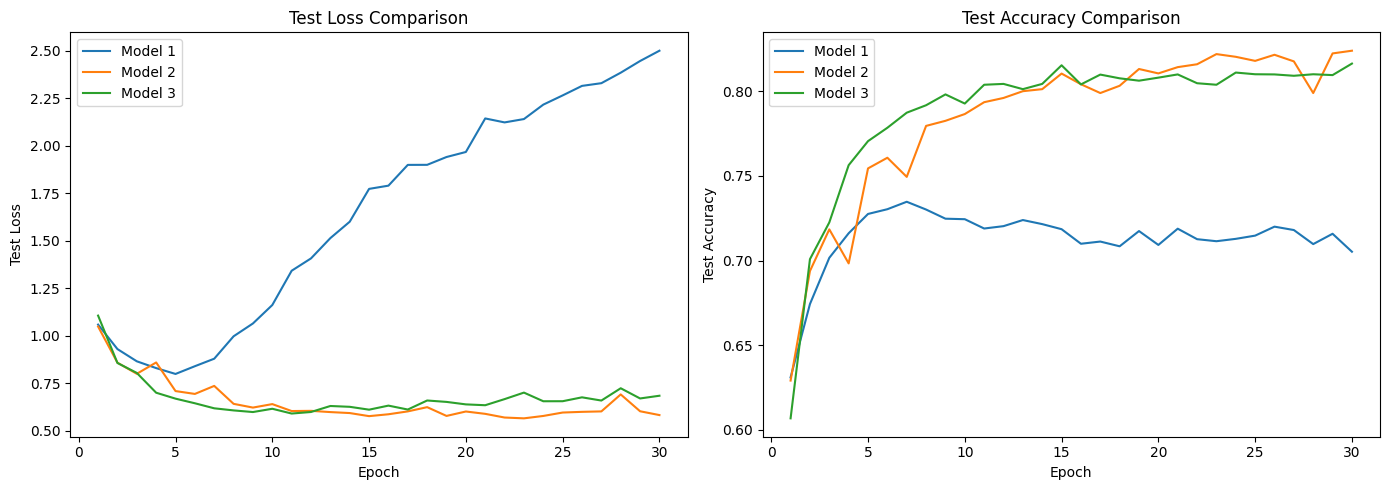

In [21]:
fig, axs = plt.subplots(1, 2, figsize=(14, 5))

for name, res in [("Model 1", res_a), ("Model 2", res_b), ("Model 3", res_c)]:
    ep = range(1, len(res['train_loss']) + 1)
    axs[0].plot(ep, res['test_loss'], label=f'{name}')
    axs[1].plot(ep, res['test_acc'],  label=f'{name}')

axs[0].set_xlabel('Epoch')
axs[0].set_ylabel('Test Loss')
axs[0].set_title('Test Loss Comparison')
axs[0].legend()

axs[1].set_xlabel('Epoch')
axs[1].set_ylabel('Test Accuracy')
axs[1].set_title('Test Accuracy Comparison')
axs[1].legend()

plt.tight_layout()
plt.show()

The comparison shows clear differences between the models. Model 1 starts to overfit after around epoch 6,as its test loss goes up while Models 2 and 3 keep improving. In the end, 2 and 3 reach a similar test loss (around 0.60), but Model C gets a bit higher accuracy, close to 0.80. Model 1 levels off around 0.72 accuracy,which shows that a  CNN without regularization doesn’t generalize as well on CIFAR-10.

## Best Model Evaluation
Now the best model is selected based on the final test accuracy from training,and then a full evaluation is run on the test set to get the final accuracy number

In [22]:
print(f"Model 1 — Test Loss: {a_test_loss:.4f}, Test Accuracy: {a_test_acc:.4f}")
print(f"Model 2 — Test Loss: {b_test_loss:.4f}, Test Accuracy: {b_test_acc:.4f}")
print(f"Model 3 — Test Loss: {c_test_loss:.4f}, Test Accuracy: {c_test_acc:.4f}")

results = {"Model 1": a_test_acc, "Model 2": b_test_acc, "Model 3": c_test_acc}
best_name = max(results, key=results.get)
print(f"\nBest model: {best_name} with {results[best_name]:.4f} accuracy")

Model 1 — Test Loss: 2.5006, Test Accuracy: 0.7052
Model 2 — Test Loss: 0.5821, Test Accuracy: 0.8239
Model 3 — Test Loss: 0.6839, Test Accuracy: 0.8163

Best model: Model 2 with 0.8239 accuracy


Model 3 achieved the best test accuracy. Even without batch normalization, the filter setup (64→128→256) with a higher dropout rate was enough to generalize well. Model 1 had the lowest performance, which makes sense given its sipmle design and lack of regularization

## Classifying Arbitrary Images
This function takes the path to a image on disk and classifies it using the best model obtained during training. the image is resized to 32x32 pixelsto match the input the network expects,and the same normalization used during training is applied before making the prediction.


In [23]:
from PIL import Image

def classify_image(image_path):
    img_transform = transforms.Compose([
        transforms.Resize((32, 32)),
        transforms.ToTensor(),
        transforms.Normalize((0.4914, 0.4822, 0.4465),
                             (0.2470, 0.2435, 0.2616))
    ])
    img_pil = Image.open(image_path).convert('RGB')
    img_input = img_transform(img_pil).unsqueeze(0).to(device)

    chosen_model = model_b
    chosen_model.eval()
    with torch.no_grad():
        logits = chosen_model(img_input)
        pred_idx = logits.argmax(dim=1).item()

    return class_names[pred_idx]

predicted_label = classify_image('../data/michi.jpg')
print(f'Predicted class: {predicted_label}')

Predicted class: cat


The function loads the image, resizes it to 32x32, and applies the same normalization used during training. yhen passes the image through the best model and returns the predicted class as a string. It’s worth noting that accuracy on random images can vary,since the model was trained on 32x32 low resolution images, resizing real world photos to that size can remove detail, which may lead to incorrect predictions.

## Personal Reflection
This activity helped me understand how different design choices affect a CNNs performance. Model 2 ended up performing the best, reaching around 80% accuracy,with Model 3 very close behind. I thought that Model 3 was going to do better because of the wider architecture,but Model 2 still held well with the bstch normalization. Model 1 showed the most overfitting, which made it clear how important regularization is. Models 2 and 3 handled this much better thanks to dropout.
Also, I noticed that small changes in the architecture can already make a noticeable difference in performance,even when everything else (like hyperparameters and data) stays the same. 

In conclusion,this made it clear that how a model is designed matters more than just making it bigger. Depth, width, and regularization have more impact than simply increasing the number of parameters.